<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Dataset Shape: (891, 12)


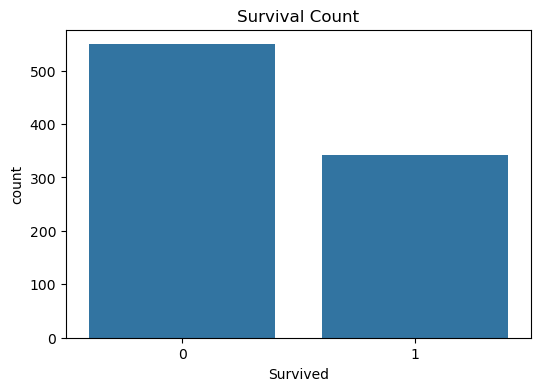

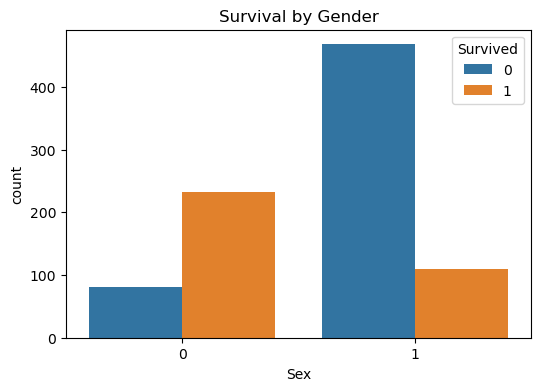

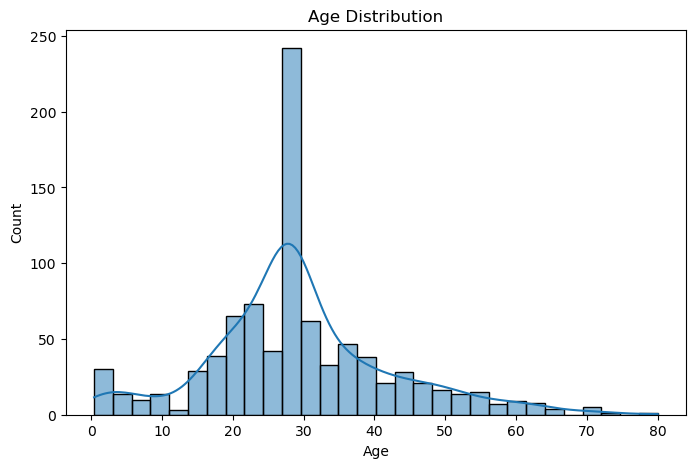

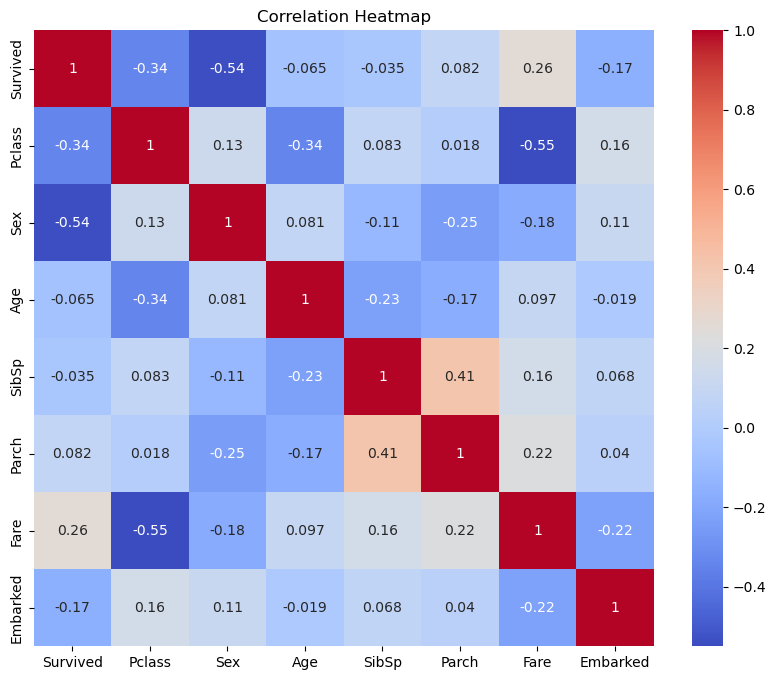

Features Shape: (891, 7)
Target Shape: (891,)
Training Data: (712, 7)
Testing Data: (179, 7)
Logistic Regression Accuracy: 81.01 %
Decision Tree Accuracy: 78.21 %
Random Forest Accuracy: 82.12 %


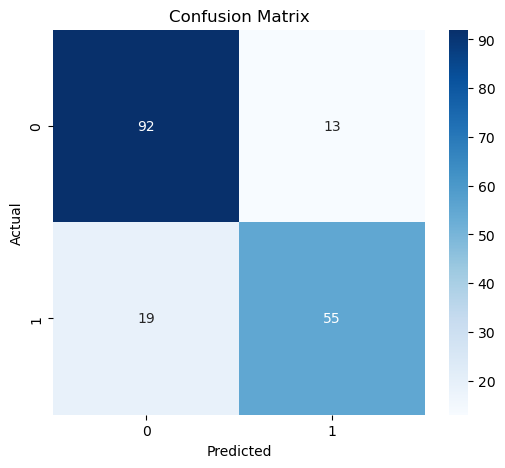

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



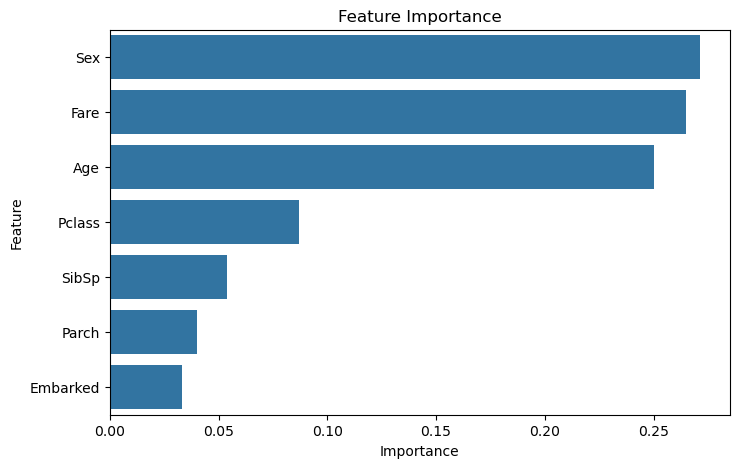

Prediction: Passenger Survived


In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")
# Load dataset

df = pd.read_csv("Titanic-Dataset.csv")
# Display first 5 rows

df.head()
# Check dataset information

df.info()
# Number of rows and columns

print("Dataset Shape:", df.shape)
# Check missing values

df.isnull().sum()
# Statistical Summary

df.describe()
# Remove unnecessary columns

df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Display first 5 rows
df.head()
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Check missing values again

df.isnull().sum()
# Convert categorical columns into numerical values

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

df.head()
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# Features (Input)
X = df.drop('Survived', axis=1)

# Target (Output)
y = df['Survived']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
# Train Logistic Regression model

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
# Train Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
# Compare model accuracies

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results['Accuracy'] = results['Accuracy'] * 100

results = results.sort_values(by='Accuracy', ascending=False)
print(results)
# Confusion Matrix

cm = confusion_matrix(y_test, rf_prediction)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Classification Report

print(classification_report(y_test, rf_prediction))
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()
# Example passenger

sample = pd.DataFrame({
    'Pclass': [1],
    'Sex': [0],      # Female
    'Age': [25],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [80],
    'Embarked': [2]
})

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")